<a href="https://colab.research.google.com/github/SenZekken193/tranducanh-duanhvnh/blob/main/Test_th%E1%BB%AD_ph%C3%A2n_t%C3%ADch_%E1%BA%A3nh_v%E1%BB%9Bi_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bước 1: Tải ảnh**
*  Đọc file ảnh từ ổ cứng vào bộ nhớ máy tính dưới dạng ma trận số.
*  Code: cv2.imread()

In [ ]:
# @title
# 1. Khai báo thư viện
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files # Thư viện đặc biệt của Colab để upload file

print("1️⃣ BƯỚC 1: ĐỌC ẢNH (IMAGE LOADING)")
print("-----------------------------------")

# 2. Tải ảnh từ máy tính lên Colab
# Khi chạy dòng này, một nút "Choose Files" sẽ hiện ra để thầy/trò chọn ảnh
print("👉 Hãy chọn một file ảnh từ máy tính của bạn:")
uploaded = files.upload()

# Lấy tên file vừa upload (để phòng trường hợp tên file thay đổi)
filename = next(iter(uploaded))

# 3. Đọc ảnh vào bộ nhớ (Dùng OpenCV)
# Hàm cv2.imread() đọc ảnh và biến nó thành ma trận số
img = cv2.imread(filename)

# 4. Kiểm tra xem ảnh đã đọc thành công chưa
if img is None:
    print(f"❌ Lỗi: Không đọc được file '{filename}'.")
else:
    print(f"✅ Đã đọc ảnh thành công!")
    print(f"   - Tên file: {filename}")
    print(f"   - Kích thước ảnh (Cao, Rộng, Kênh màu): {img.shape}")
    print(f"   - Kiểu dữ liệu: {img.dtype} (Thường là uint8)")

    # 5. Hiển thị ảnh gốc để kiểm tra
    # Lưu ý: OpenCV đọc theo hệ màu BGR (Xanh-Lục-Đỏ),
    # cần chuyển sang RGB để Matplotlib hiển thị đúng màu mắt người nhìn.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Ảnh gốc: {filename}")
    plt.axis('off') # Tắt khung trục tọa độ cho đẹp
    plt.show()

1️⃣ BƯỚC 1: ĐỌC ẢNH (IMAGE LOADING)
-----------------------------------
👉 Hãy chọn một file ảnh từ máy tính của bạn:


# Bước 2: Xám hóa (Chuyển bức ảnh sang màu GrayScale)
*   Chuyển ảnh màu (3 kênh RGB) sang ảnh xám (1 kênh) để giảm khối lượng dữ liệu xuống 1/3.
*   Code: cv2.cvtColor(..., cv2.COLOR_BGR2GRAY)





-----------------------------------
2️⃣ BƯỚC 2: XÁM HÓA (GRAYSCALE CONVERSION)
-----------------------------------
✅ Đã chuyển đổi thành công!
   - Kích thước ảnh gốc: (374, 406, 3) (Có số 3 ở cuối -> 3 kênh màu)
   - Kích thước ảnh xám: (374, 406) (Mất số 3 -> Chỉ còn Chiều cao x Chiều rộng)


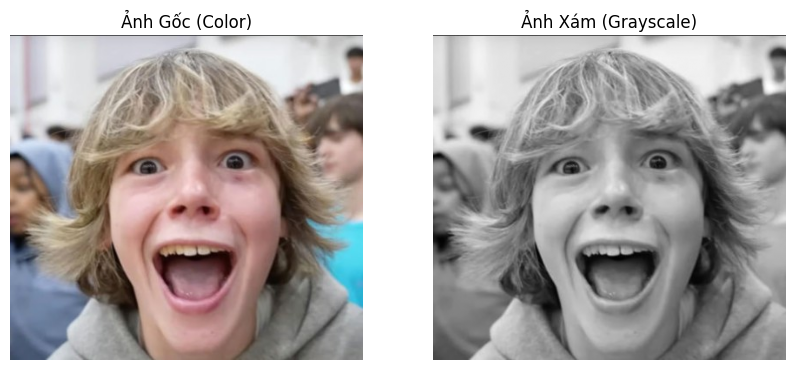

In [ ]:
# --- (Chạy tiếp sau khi đã có biến 'img' từ Bước 1) ---

print("\n-----------------------------------")
print("2️⃣ BƯỚC 2: XÁM HÓA (GRAYSCALE CONVERSION)")
print("-----------------------------------")

# Kiểm tra xem Bước 1 đã chạy chưa
if 'img' not in locals() or img is None:
    print("❌ Lỗi: Chưa tìm thấy ảnh! Thầy/trò vui lòng chạy Code Bước 1 trước nhé.")
else:
    # 1. Thực hiện chuyển đổi từ BGR sang Grayscale
    # Hàm này gộp 3 kênh màu (Xanh, Đỏ, Lục) thành 1 kênh duy nhất (Độ sáng)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. In thông số để so sánh
    print(f"✅ Đã chuyển đổi thành công!")
    print(f"   - Kích thước ảnh gốc: {img.shape} (Có số 3 ở cuối -> 3 kênh màu)")
    print(f"   - Kích thước ảnh xám: {img_gray.shape} (Mất số 3 -> Chỉ còn Chiều cao x Chiều rộng)")

    # 3. Hiển thị hình ảnh so sánh Trực quan
    plt.figure(figsize=(10, 5))

    # Hình bên trái: Ảnh gốc (Màu)
    plt.subplot(1, 2, 1)
    # Nhớ chuyển sang RGB để hiển thị đúng màu
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Ảnh Gốc (Color)")
    plt.axis('off')

    # Hình bên phải: Ảnh xám (Grayscale)
    plt.subplot(1, 2, 2)
    # LƯU Ý QUAN TRỌNG: Phải thêm cmap='gray',
    # nếu không Matplotlib sẽ tự tô màu xanh vàng (heatmap) cho ảnh.
    plt.imshow(img_gray, cmap='gray')
    plt.title("Ảnh Xám (Grayscale)")
    plt.axis('off')

    plt.show()


# Bước 3: Thay đổi kích thước (Resizing)


*   Đưa tất cả ảnh về cùng một kích thước cố định (ví dụ: $32 \times 32$ pixel) để đồng bộ đầu vào cho AI.
*   Code: cv2.resize()




-----------------------------------
3️⃣ BƯỚC 3: THAY ĐỔI KÍCH THƯỚC (RESIZING)
-----------------------------------
✅ Đã resize thành công về (32, 32)!
   - Số lượng điểm ảnh ban đầu: 151844 pixels
   - Số lượng điểm ảnh lúc sau: 1024 pixels
   📉 Đã giảm dữ liệu đi: 148 lần!


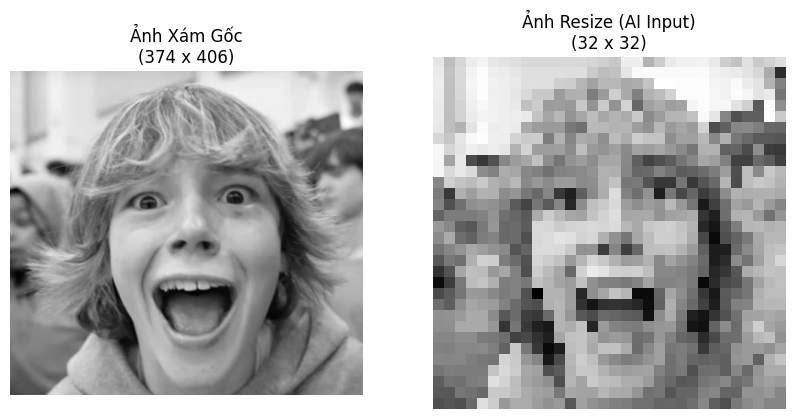

In [ ]:
# --- (Chạy tiếp sau khi đã có biến 'img_gray' từ Bước 2) ---

print("\n-----------------------------------")
print("3️⃣ BƯỚC 3: THAY ĐỔI KÍCH THƯỚC (RESIZING)")
print("-----------------------------------")

# Kiểm tra xem Bước 2 đã chạy chưa
if 'img_gray' not in locals():
    print("❌ Lỗi: Chưa có ảnh xám! Vui lòng chạy Code Bước 2 trước.")
else:
    # 1. Thiết lập kích thước mục tiêu (Target Size)
    # 32x32 là kích thước chuẩn cho nhiều bài tập AI nhập môn (như bộ dữ liệu CIFAR-10)
    NEW_SIZE = (32, 32)

    # 2. Thực hiện Resize
    img_small = cv2.resize(img_gray, NEW_SIZE)

    # 3. In thông số để so sánh sự thay đổi "khủng khiếp" về dữ liệu
    height, width = img_gray.shape
    original_pixels = height * width
    new_pixels = NEW_SIZE[0] * NEW_SIZE[1]

    print(f"✅ Đã resize thành công về {NEW_SIZE}!")
    print(f"   - Số lượng điểm ảnh ban đầu: {original_pixels} pixels")
    print(f"   - Số lượng điểm ảnh lúc sau: {new_pixels} pixels")
    print(f"   📉 Đã giảm dữ liệu đi: {round(original_pixels / new_pixels)} lần!")

    # 4. Hiển thị so sánh
    plt.figure(figsize=(10, 5))

    # Hình bên trái: Ảnh xám gốc
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title(f"Ảnh Xám Gốc\n({height} x {width})")
    plt.axis('off')

    # Hình bên phải: Ảnh nhỏ 32x32
    plt.subplot(1, 2, 2)
    # Mẹo: Dùng interpolation='nearest' để nhìn rõ từng ô vuông pixel
    # Nếu không có lệnh này, Python sẽ tự làm mờ ảnh trông rất nhòe.
    plt.imshow(img_small, cmap='gray', interpolation='nearest')
    plt.title(f"Ảnh Resize (AI Input)\n(32 x 32)")
    plt.axis('off')

    plt.show()

# Bước 4: Giảm nhiễu (Denoising/Blurring)

*   Làm mờ nhẹ (Gaussian Blur) để loại bỏ các điểm nhiễu (hạt sạn), giúp các bước sau không bị nhận diện sai.
*   Code: cv2.GaussianBlur()


-----------------------------------
4️⃣ BƯỚC 4: GIẢM NHIỄU (DENOISING / BLURRING)
-----------------------------------
✅ Đã giảm nhiễu thành công với Kernel (5, 5)!


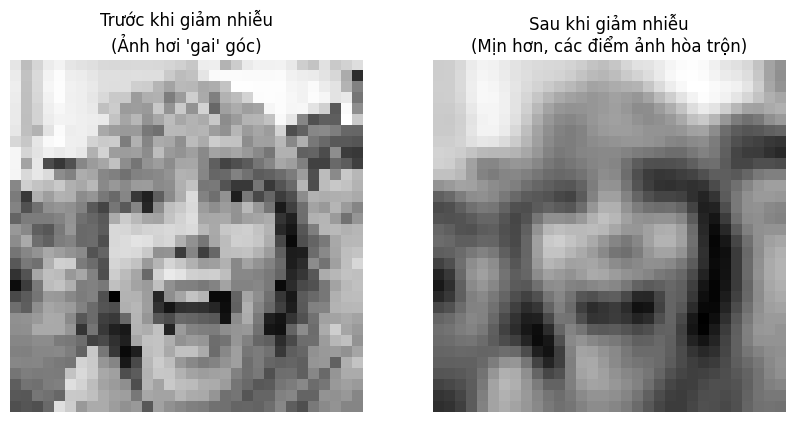


🔍 So sánh sự thay đổi của một điểm ảnh (Ví dụ tại vị trí 10,10):
   - Giá trị cũ (Gắt): 113
   - Giá trị mới (Mịn): 134 (Đã được trung bình cộng với hàng xóm)


In [ ]:
# --- (Chạy tiếp sau khi đã có biến 'img_small' từ Bước 3) ---

print("\n-----------------------------------")
print("4️⃣ BƯỚC 4: GIẢM NHIỄU (DENOISING / BLURRING)")
print("-----------------------------------")

# Kiểm tra xem Bước 3 đã chạy chưa
if 'img_small' not in locals():
    print("❌ Lỗi: Chưa có ảnh Resize! Vui lòng chạy Code Bước 3 trước.")
else:
    # 1. Cấu hình độ mạnh của việc làm mờ (Kernel Size)
    # Số (5, 5) nghĩa là: Với mỗi điểm ảnh, hãy lấy trung bình cộng của 5x5 điểm xung quanh nó.
    # Số càng to (ví dụ 9,9) thì ảnh càng mờ. Số phải là số lẻ (3, 5, 7...).
    KERNEL_SIZE = (5, 5)

    # 2. Thực hiện làm mờ bằng thuật toán Gaussian
    img_blur = cv2.GaussianBlur(img_small, KERNEL_SIZE, 0)

    print(f"✅ Đã giảm nhiễu thành công với Kernel {KERNEL_SIZE}!")

    # 3. Hiển thị so sánh
    plt.figure(figsize=(10, 5))

    # Hình bên trái: Ảnh Resize (Có thể hơi gắt/nhiễu)
    plt.subplot(1, 2, 1)
    plt.imshow(img_small, cmap='gray', interpolation='nearest')
    plt.title("Trước khi giảm nhiễu\n(Ảnh hơi 'gai' góc)")
    plt.axis('off')

    # Hình bên phải: Ảnh đã làm mờ
    plt.subplot(1, 2, 2)
    plt.imshow(img_blur, cmap='gray', interpolation='nearest')
    plt.title(f"Sau khi giảm nhiễu\n(Mịn hơn, các điểm ảnh hòa trộn)")
    plt.axis('off')

    plt.show()

    # 4. Minh họa dữ liệu số thay đổi thế nào
    print("\n🔍 So sánh sự thay đổi của một điểm ảnh (Ví dụ tại vị trí 10,10):")
    print(f"   - Giá trị cũ (Gắt): {img_small[10,10]}")
    print(f"   - Giá trị mới (Mịn): {img_blur[10,10]} (Đã được trung bình cộng với hàng xóm)")

# Bước 5: Trích xuất đặc trưng hoặc Phân ngưỡng (Feature Extraction / Thresholding)


*   Thao tác: cv2.Canny() hoặc cv2.threshold()
*   Đây là bước "chốt hạ" về mặt hình ảnh. Lúc này ảnh đã sạch (đã giảm nhiễu), đúng kích thước (đã resize) và đúng định dạng (đã xám). Kết quả thu được là hình dáng vật thể rõ nét nhất.


-----------------------------------
5️⃣ BƯỚC 5: TRÍCH XUẤT ĐẶC TRƯNG / PHÂN NGƯỠNG
-----------------------------------
✅ Đã trích xuất xong!


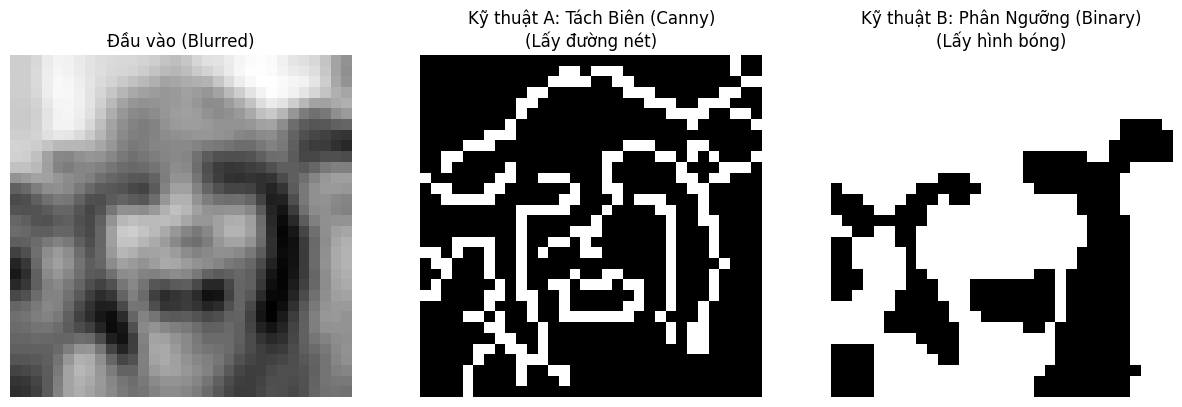


🔍 Kiểm tra giá trị pixel trong ảnh 'Phân ngưỡng':
   - Chỉ còn lại các giá trị: [  0 255]
   👉 (0 là màu đen tuyệt đối, 255 là màu trắng tuyệt đối. Không còn màu xám lửng lơ!)


In [ ]:
# --- (Chạy tiếp sau khi đã có biến 'img_blur' từ Bước 4) ---

print("\n-----------------------------------")
print("5️⃣ BƯỚC 5: TRÍCH XUẤT ĐẶC TRƯNG / PHÂN NGƯỠNG")
print("-----------------------------------")

# Kiểm tra xem Bước 4 đã chạy chưa
if 'img_blur' not in locals():
    print("❌ Lỗi: Chưa có ảnh giảm nhiễu! Vui lòng chạy Code Bước 4 trước.")
else:
    # --- KỸ THUẬT A: TÁCH BIÊN (CANNY EDGE DETECTION) ---
    # Giúp AI nhìn thấy "bộ khung xương" của vật thể
    # 100, 200 là ngưỡng dưới và trên để lọc các cạnh yếu/mạnh
    edges = cv2.Canny(img_blur, 100, 200)

    # --- KỸ THUẬT B: PHÂN NGƯỠNG (BINARY THRESHOLDING) ---
    # Giúp AI tách vật thể ra khỏi nền (Cắt bóng)
    # Nếu điểm ảnh sáng hơn 127 -> Thành màu Trắng (255)
    # Nếu điểm ảnh tối hơn 127 -> Thành màu Đen (0)
    _, binary = cv2.threshold(img_blur, 127, 255, cv2.THRESH_BINARY)

    print(f"✅ Đã trích xuất xong!")

    # HIỂN THỊ KẾT QUẢ SO SÁNH
    plt.figure(figsize=(15, 5))

    # Hình 1: Ảnh đầu vào (Đã làm mờ)
    plt.subplot(1, 3, 1)
    plt.imshow(img_blur, cmap='gray', interpolation='nearest')
    plt.title("Đầu vào (Blurred)")
    plt.axis('off')

    # Hình 2: Kết quả Tách biên (Canny)
    plt.subplot(1, 3, 2)
    plt.imshow(edges, cmap='gray', interpolation='nearest')
    plt.title("Kỹ thuật A: Tách Biên (Canny)\n(Lấy đường nét)")
    plt.axis('off')

    # Hình 3: Kết quả Phân ngưỡng (Threshold)
    plt.subplot(1, 3, 3)
    plt.imshow(binary, cmap='gray', interpolation='nearest')
    plt.title("Kỹ thuật B: Phân Ngưỡng (Binary)\n(Lấy hình bóng)")
    plt.axis('off')

    plt.show()

    # In ra dữ liệu để chứng minh sự đơn giản hóa
    print("\n🔍 Kiểm tra giá trị pixel trong ảnh 'Phân ngưỡng':")
    # np.unique giúp liệt kê các giá trị duy nhất xuất hiện trong ma trận
    unique_values = np.unique(binary)
    print(f"   - Chỉ còn lại các giá trị: {unique_values}")
    print("   👉 (0 là màu đen tuyệt đối, 255 là màu trắng tuyệt đối. Không còn màu xám lửng lơ!)")

# Bước 6: Chuẩn hóa (Normalization)

*   Chia giá trị pixel cho 255.0 để chuyển từ số nguyên lớn $[0, 255]$ về số thực nhỏ $[0, 1]$, giúp thuật toán AI tính toán hiệu quả hơn.
*   Code: img / 255.0





-----------------------------------
6️⃣ BƯỚC 6: CHUẨN HÓA (NORMALIZATION)
-----------------------------------
✅ Đã chuẩn hóa thành công!
   - Kiểu dữ liệu cũ (Ảnh): uint8 (Số nguyên uint8)
   - Kiểu dữ liệu mới (Toán): float64 (Số thực float64)
   - Giá trị lớn nhất cũ: 255
   - Giá trị lớn nhất mới: 1.0

🔍 So sánh dữ liệu Ma trận (Góc 5x5 pixel):

--- Ma trận trước khi chuẩn hóa (uint8) ---
[[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]

--- Ma trận sau khi chuẩn hóa (float) ---
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


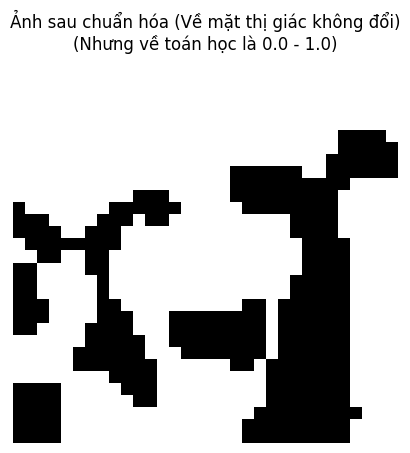

In [ ]:
# --- (Chạy tiếp sau khi đã có biến 'binary' từ Bước 5) ---

print("\n-----------------------------------")
print("6️⃣ BƯỚC 6: CHUẨN HÓA (NORMALIZATION)")
print("-----------------------------------")

# Kiểm tra xem Bước 5 đã chạy chưa
if 'binary' not in locals():
    print("❌ Lỗi: Chưa có ảnh phân ngưỡng! Vui lòng chạy Code Bước 5 trước.")
else:
    # 1. Thực hiện phép chia để chuẩn hóa
    # Lưu ý quan trọng: Phải chia cho 255.0 (có chấm không) để Python hiểu là chia lấy số thập phân
    # Chúng ta sẽ dùng ảnh 'binary' (đang là 0 và 255) để chuyển về 0.0 và 1.0
    img_norm = binary / 255.0

    print(f"✅ Đã chuẩn hóa thành công!")

    # 2. Kiểm tra sự thay đổi về Kiểu dữ liệu (Data Type)
    print(f"   - Kiểu dữ liệu cũ (Ảnh): {binary.dtype} (Số nguyên uint8)")
    print(f"   - Kiểu dữ liệu mới (Toán): {img_norm.dtype} (Số thực float64)")

    # 3. Kiểm tra sự thay đổi về Giá trị (Value Range)
    print(f"   - Giá trị lớn nhất cũ: {np.max(binary)}")
    print(f"   - Giá trị lớn nhất mới: {np.max(img_norm)}")

    # 4. Hiển thị ma trận để học sinh thấy sự khác biệt
    print("\n🔍 So sánh dữ liệu Ma trận (Góc 5x5 pixel):")

    print("\n--- Ma trận trước khi chuẩn hóa (uint8) ---")
    print(binary[0:5, 0:5])

    print("\n--- Ma trận sau khi chuẩn hóa (float) ---")
    # Chúng ta sẽ thấy các dấu chấm động (1. thay vì 1, 0. thay vì 0)
    print(img_norm[0:5, 0:5])

    # 5. Hiển thị ảnh (Sẽ trông giống hệt nhau vì máy tính tự hiểu tỉ lệ)
    plt.figure(figsize=(5, 5))
    plt.imshow(img_norm, cmap='gray', interpolation='nearest')
    plt.title("Ảnh sau chuẩn hóa (Về mặt thị giác không đổi)\n(Nhưng về toán học là 0.0 - 1.0)")
    plt.axis('off')
    plt.show()

# Bước 7: Duỗi phẳng (Flattening)

*   Biến đổi ma trận ảnh 2 chiều (ví dụ $32 \times 32$) thành một vector hàng ngang 1 chiều (ví dụ 1024 phần tử) để đưa vào lớp đầu vào (Input Layer) của mạng nơ-ron.
*   Code: img.flatten()


-----------------------------------
7️⃣ BƯỚC 7: DUỖI PHẲNG (FLATTENING)
-----------------------------------
✅ Đã duỗi phẳng thành công!
   - Kích thước cũ (Ma trận 2D): (32, 32) -> (Cao, Rộng)
   - Kích thước mới (Vector 1D): (1024,) -> (Tổng số điểm ảnh)
   👉 (Kiểm chứng: 32 x 32 đúng bằng 1024 phần tử!)


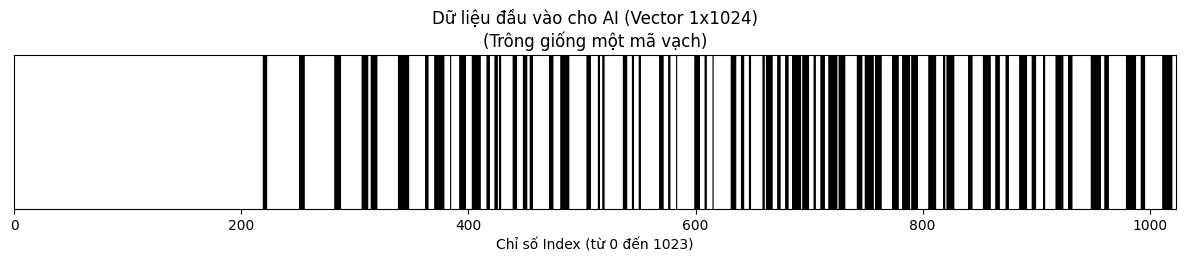


🔍 Soi dữ liệu trong Vector:
   - 10 giá trị đầu tiên: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
   - 10 giá trị cuối cùng: [0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]

🎉 CHÚC MỪNG! Dữ liệu này đã sẵn sàng để đưa vào Input Layer của AI!


In [ ]:
# --- (Chạy tiếp sau khi đã có biến 'img_norm' từ Bước 6) ---

print("\n-----------------------------------")
print("7️⃣ BƯỚC 7: DUỖI PHẲNG (FLATTENING)")
print("-----------------------------------")

# Kiểm tra xem Bước 6 đã chạy chưa
if 'img_norm' not in locals():
    print("❌ Lỗi: Chưa có ảnh chuẩn hóa! Vui lòng chạy Code Bước 6 trước.")
else:
    # 1. Thực hiện Duỗi phẳng (Flatten)
    # Lệnh này cắt từng hàng của ma trận 32x32 và nối đuôi nhau thành 1 hàng dài
    img_vector = img_norm.flatten()

    print(f"✅ Đã duỗi phẳng thành công!")

    # 2. Kiểm tra sự thay đổi về Kích thước (Shape)
    # Đây là điểm quan trọng nhất học sinh cần thấy
    print(f"   - Kích thước cũ (Ma trận 2D): {img_norm.shape} -> (Cao, Rộng)")
    print(f"   - Kích thước mới (Vector 1D): {img_vector.shape} -> (Tổng số điểm ảnh)")

    # Kiểm tra toán học: 32 * 32 có bằng 1024 không?
    if img_vector.shape[0] == 32 * 32:
        print("   👉 (Kiểm chứng: 32 x 32 đúng bằng 1024 phần tử!)")

    # 3. Hiển thị Vector dưới dạng "Mã vạch" (Barcode)
    # Vì vector là 1 hàng ngang rất dài, ta vẽ nó như một mã vạch để dễ hình dung
    plt.figure(figsize=(15, 2))

    # Chúng ta phải reshape lại thành (1, 1024) để imshow hiểu được đây là ảnh 1 dòng
    plt.imshow(img_vector.reshape(1, -1), cmap='gray', aspect='auto')

    plt.title(f"Dữ liệu đầu vào cho AI (Vector 1x1024)\n(Trông giống một mã vạch)")
    plt.xlabel("Chỉ số Index (từ 0 đến 1023)")
    plt.yticks([]) # Tắt trục tung vì chỉ có 1 dòng
    plt.show()

    # 4. In thử dữ liệu đầu và cuối của Vector
    print("\n🔍 Soi dữ liệu trong Vector:")
    print(f"   - 10 giá trị đầu tiên: {img_vector[:10]}")
    print(f"   - 10 giá trị cuối cùng: {img_vector[-10:]}")
    print("\n🎉 CHÚC MỪNG! Dữ liệu này đã sẵn sàng để đưa vào Input Layer của AI!")